In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.inspection import permutation_importance

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 100)


In [2]:
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

df = pd.concat([train_df, test_df], ignore_index=True)

print("📦 شكل البيانات:", df.shape)
display(df.head())
print("\n📋 أعمدة البيانات:")
print(df.columns.tolist())


📦 شكل البيانات: (129880, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied



📋 أعمدة البيانات:
['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


In [ ]:
df_clean = df.copy()

df_clean["satisfaction_numeric"] = df_clean["satisfaction"].map({
    "satisfied": 1,
    "neutral or dissatisfied": 0
})

df_clean = df_clean.dropna(subset=["satisfaction", "satisfaction_numeric"])

df_clean = df_clean[(df_clean["Age"] >= 18) & (df_clean["Age"] <= 80)]
df_clean = df_clean[(df_clean["Flight Distance"] >= 50) & (df_clean["Flight Distance"] <= 7000)]

for c in ["Departure Delay in Minutes", "Arrival Delay in Minutes"]:
    if c in df_clean.columns:
        df_clean = df_clean[df_clean[c].notna()]
        df_clean = df_clean[df_clean[c] >= 0]
        df_clean.loc[df_clean[c] > 200, c] = 200 

print("✅ بعد التنظيف:", df_clean.shape)


✅ بعد التنظيف: (119642, 26)


In [ ]:

bins_age = [17, 30, 60, 80]
labels_age = ["Young(18-30)", "Middle(31-60)", "Senior(61-80)"]
df_clean["AgeBand"] = pd.cut(df_clean["Age"], bins=bins_age, labels=labels_age, include_lowest=True)


bins_dist = [0, 1500, 3500, 8000]
labels_dist = ["Short", "Medium", "Long"]
df_clean["DistanceBand"] = pd.cut(df_clean["Flight Distance"], bins=bins_dist, labels=labels_dist, include_lowest=True)


def delay_band(x):
    if x <= 30: return "Short(<=30m)"
    if x <= 120: return "Medium(31-120m)"
    return "Long(>120m)"

for c in ["Departure Delay in Minutes", "Arrival Delay in Minutes"]:
    if c in df_clean.columns:
        df_clean[c + " Band"] = df_clean[c].apply(delay_band)

display(df_clean[["Age","AgeBand","Flight Distance","DistanceBand"]].head())


,Age,AgeBand,Flight Distance,DistanceBand
1,25,Young(18-30),235,Short
2,26,Young(18-30),1142,Short
3,25,Young(18-30),562,Short
4,61,Senior(61-80),214,Short
5,26,Young(18-30),1180,Short


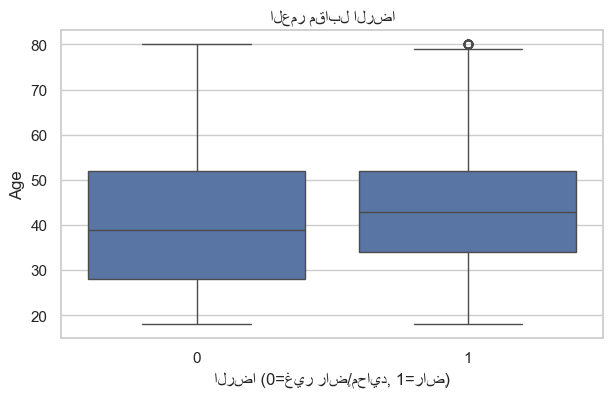

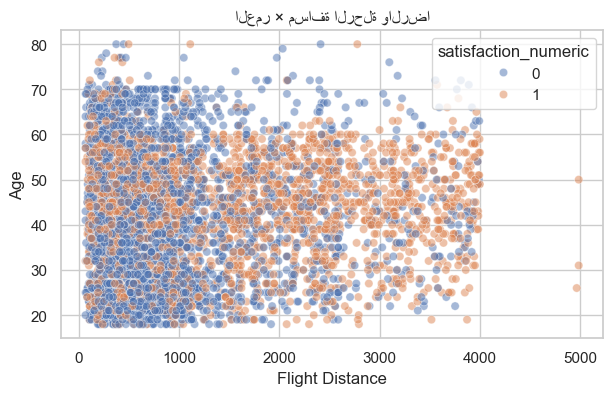

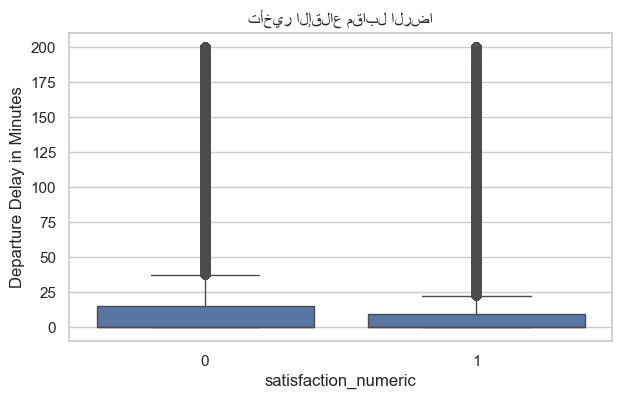

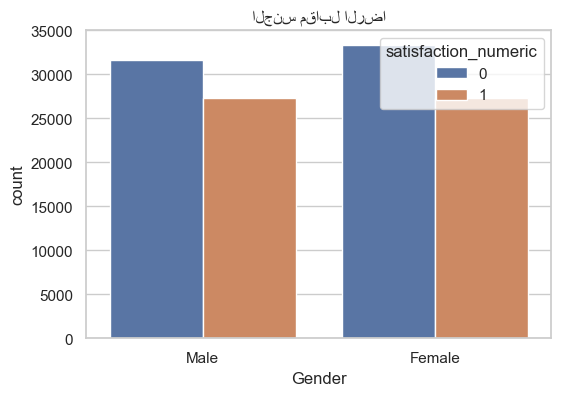

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(x="satisfaction_numeric", y="Age", data=df_clean)
plt.title("العمر مقابل الرضا")
plt.xlabel("الرضا (0=غير راضٍ/محايد, 1=راضٍ)")
plt.show()

plt.figure(figsize=(7,4))
sns.scatterplot(data=df_clean.sample(min(5000, len(df_clean)), random_state=42),
                x="Flight Distance", y="Age", hue="satisfaction_numeric", alpha=0.5)
plt.title("العمر × مسافة الرحلة والرضا")
plt.show()

if "Departure Delay in Minutes" in df_clean.columns:
    plt.figure(figsize=(7,4))
    sns.boxplot(x="satisfaction_numeric", y="Departure Delay in Minutes", data=df_clean)
    plt.title("تأخير الإقلاع مقابل الرضا")
    plt.show()

if "Gender" in df_clean.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x="Gender", hue="satisfaction_numeric", data=df_clean)
    plt.title("الجنس مقابل الرضا")
    plt.show()


🧩 أعمدة الخدمات المستخدمة: ['Inflight wifi service', 'Food and drink', 'Seat comfort', 'On-board service', 'Inflight entertainment', 'Ease of Online booking', 'Online boarding', 'Gate location', 'Baggage handling', 'Checkin service', 'Cleanliness']


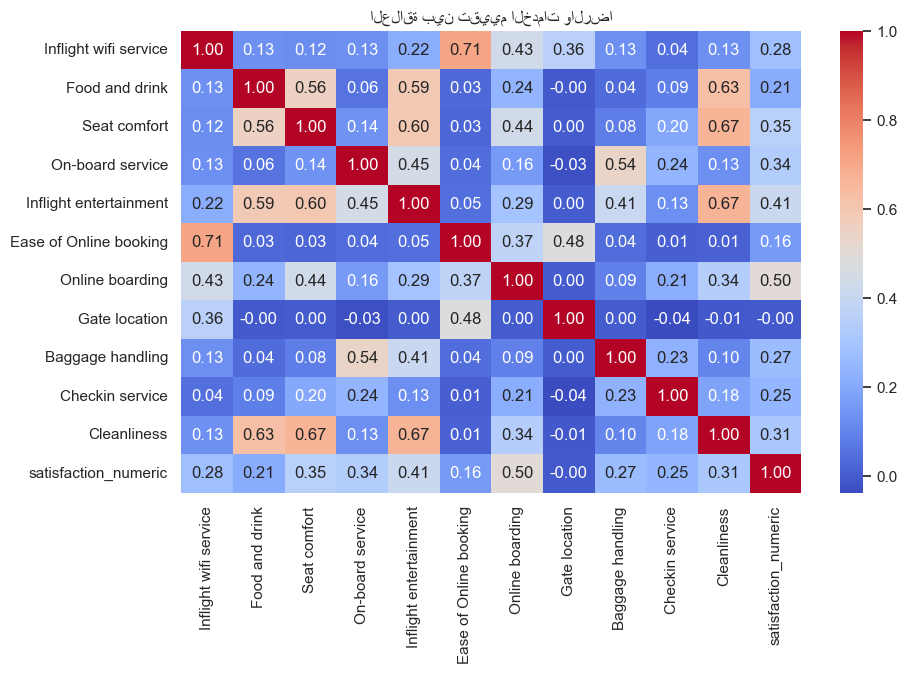

In [6]:
service_cols = [c for c in [
    "Inflight wifi service","Food and drink","Seat comfort","On-board service",
    "Inflight entertainment","Ease of Online booking","Online boarding",
    "Gate location","Baggage handling","Checkin service","Cleanliness"
] if c in df_clean.columns]

print("🧩 أعمدة الخدمات المستخدمة:", service_cols)

corr_df = df_clean[service_cols + ["satisfaction_numeric"]].corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("العلاقة بين تقييم الخدمات والرضا")
plt.show()


In [ ]:
num_cols = [c for c in [
    "Age","Flight Distance","Departure Delay in Minutes","Arrival Delay in Minutes"
] if c in df_clean.columns]

cat_cols = [c for c in [
    "Gender","Customer Type","Type of Travel","Class",
    "AgeBand","DistanceBand",
    "Departure Delay in Minutes Band","Arrival Delay in Minutes Band"
] if c in df_clean.columns]

num_cols += service_cols

X = df_clean[num_cols + cat_cols]
y = df_clean["satisfaction_numeric"].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

ct = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)


In [ ]:
log_reg = Pipeline(steps=[
    ("prep", ct),
    ("clf", LogisticRegression(max_iter=200, n_jobs=None))  
])

log_reg.fit(X_train, y_train)
pred_lr = log_reg.predict(X_val)
proba_lr = log_reg.predict_proba(X_val)[:,1]

print("✅ Logistic Regression")
print("Accuracy:", round(accuracy_score(y_val, pred_lr), 3))
print("ROC-AUC :", round(roc_auc_score(y_val, proba_lr), 3))

print("\nClassification Report:\n", classification_report(y_val, pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_val, pred_lr))


✅ Logistic Regression
Accuracy: 0.846
ROC-AUC : 0.912

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.85      0.86     16258
           1       0.83      0.84      0.83     13653

    accuracy                           0.85     29911
   macro avg       0.85      0.85      0.85     29911
weighted avg       0.85      0.85      0.85     29911

Confusion Matrix:
 [[13840  2418]
 [ 2177 11476]]


c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


🌲 Random Forest
Accuracy: 0.846
ROC-AUC : 0.912

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96     16258
           1       0.97      0.94      0.95     13653

    accuracy                           0.96     29911
   macro avg       0.96      0.96      0.96     29911
weighted avg       0.96      0.96      0.96     29911

Confusion Matrix:
 [[15830   428]
 [  788 12865]]

🔎 أعلى 15 سمة تأثيرًا (Permutation Importance):


,feature,importance_mean,importance_std
17,Type of Travel,0.160018,0.001382
4,Inflight wifi service,0.127903,0.001564
16,Customer Type,0.086463,0.000945
10,Online boarding,0.036244,0.000885
12,Baggage handling,0.030748,0.000971
13,Checkin service,0.029775,0.000560
6,Seat comfort,0.024797,0.000844
14,Cleanliness,0.022049,0.000755
18,Class,0.020197,0.000508
7,On-board service,0.009281,0.000641


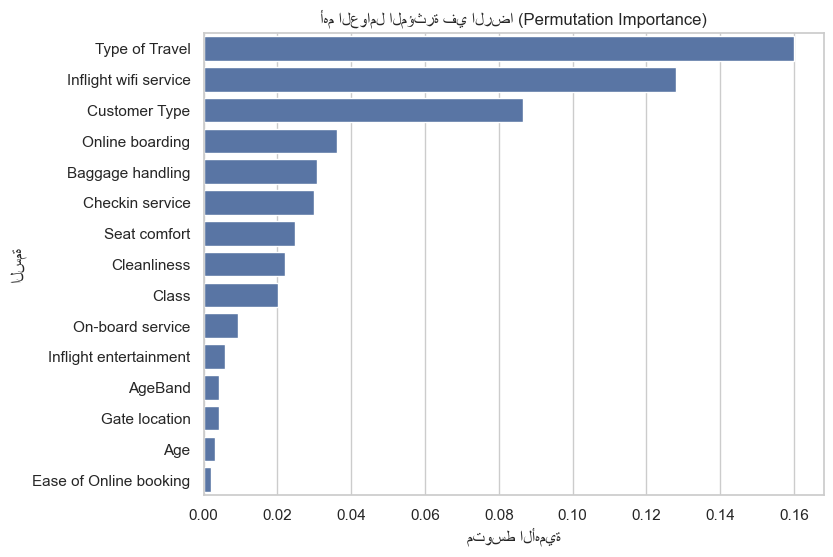

In [ ]:
rf = Pipeline(steps=[
    ("prep", ct),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_val)
proba_rf = rf.predict_proba(X_val)[:,1]

print("🌲 Random Forest")
print("Accuracy:", round(accuracy_score(y_val, pred_lr), 3))
print("ROC-AUC :", round(roc_auc_score(y_val, proba_lr), 3))

print("\nClassification Report:\n", classification_report(y_val, pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_val, pred_rf))

r = permutation_importance(rf, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1)
importances = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std
}).sort_values("importance_mean", ascending=False)

print("\n🔎 أعلى 15 سمة تأثيرًا (Permutation Importance):")
display(importances.head(15))

plt.figure(figsize=(8,6))
sns.barplot(data=importances.head(15), x="importance_mean", y="feature")
plt.title("أهم العوامل المؤثرة في الرضا (Permutation Importance)")
plt.xlabel("متوسط الأهمية")
plt.ylabel("السمة")
plt.show()


In [ ]:
top_feats = importances.head(8)["feature"].tolist()

insights = []

if any("Departure Delay" in f or "Arrival Delay" in f for f in top_feats):
    insights.append("تقليل التأخيرات (الإقلاع/الوصول) أولوية قصوى لرفع الرضا.")

if any(k in " ".join(top_feats) for k in ["Seat comfort","Cleanliness","Inflight wifi service","On-board service","Food and drink"]):
    insights.append("تحسين جودة الخدمات على متن الطائرة (الراحة/النظافة/الطعام/الواي فاي) له أثر مباشر على الرضا.")

if any("Class" in f or "Type of Travel" in f for f in top_feats):
    insights.append("تخصيص التجربة حسب فئة ونوع السفر (عمل/شخصي) يزيد الرضا ويقلل الشكاوى.")


if any("Distance" in f for f in top_feats):
    insights.append("الرحلات الطويلة تحتاج مزايا إضافية (وجبات/ترفيه/مساحة أكبر) لتقليل الاستياء.")


if any("Age" in f for f in top_feats):
    insights.append("تحسين الخدمات للفئات العمرية الأكبر (مساعدة إضافية/مقاعد مريحة) يرفع الرضا.")

print("🧭 توصيات تحسين مستندة إلى التحليل:\n- " + "\n- ".join(insights) if insights else "لا توجد توصيات خاصة – راجعي الأهمية والرسوم لاختيار أولويات التحسين.")


🧭 توصيات تحسين مستندة إلى التحليل:
- تحسين جودة الخدمات على متن الطائرة (الراحة/النظافة/الطعام/الواي فاي) له أثر مباشر على الرضا.
- تخصيص التجربة حسب فئة ونوع السفر (عمل/شخصي) يزيد الرضا ويقلل الشكاوى.


In [11]:
print("""
📌 ملخص تنقيبي:
1) بعد تنظيف القيم الشاذة (العمر 18–80، المسافة 50–7000 كم، التأخير قُصّ إلى 200 دقيقة)، 
   قمنا بتقسيم العمر والمسافة والتأخيرات إلى فئات لتسهيل الفهم.
2) بصريًا: التأخيرات المرتفعة تقلل الرضا، والمقاعد/الخدمات الجيدة ترفع الرضا، 
   والرحلات الطويلة قد تتطلب عناية إضافية.
3) تنبؤيًا: استخدمنا Logistic Regression و Random Forest.
   تم تقييم الأداء بـ Accuracy و ROC-AUC.
4) للتفسير: اعتمدنا Permutation Importance لتحديد أهم السمات المؤثرة على الرضا.
5) التحسين: الأولوية لتقليل التأخيرات وتحسين خدمات المقصورة، 
   مع تخصيص أفضل لفئات/أنواع السفر، والاهتمام بكبار السن في الرحلات الطويلة.
""")



📌 ملخص تنقيبي:
1) بعد تنظيف القيم الشاذة (العمر 18–80، المسافة 50–7000 كم، التأخير قُصّ إلى 200 دقيقة)، 
   قمنا بتقسيم العمر والمسافة والتأخيرات إلى فئات لتسهيل الفهم.
2) بصريًا: التأخيرات المرتفعة تقلل الرضا، والمقاعد/الخدمات الجيدة ترفع الرضا، 
   والرحلات الطويلة قد تتطلب عناية إضافية.
3) تنبؤيًا: استخدمنا Logistic Regression و Random Forest.
   تم تقييم الأداء بـ Accuracy و ROC-AUC.
4) للتفسير: اعتمدنا Permutation Importance لتحديد أهم السمات المؤثرة على الرضا.
5) التحسين: الأولوية لتقليل التأخيرات وتحسين خدمات المقصورة، 
   مع تخصيص أفضل لفئات/أنواع السفر، والاهتمام بكبار السن في الرحلات الطويلة.

